# Australian Fuel Market — Competitor Pricing Analysis
## Notebook 2: Competitor Pricing Analysis

This notebook answers three questions:

1. **Market positioning** — Where does 7-Eleven sit in the market relative to competitors over time, and has that position changed?
2. **Price spread analysis** — How many cents per litre above or below the cheapest competitor is 7-Eleven on any given day, and how does that vary across the competitive cycle?
3. **Competitor response lag** — When the market drops, how quickly does each brand follow? Is 7-Eleven a price leader or a follower?

Each analysis ends with a plain-English interpretation written as a briefing note.

---

**Input:** `data/processed/daily_brand_averages.parquet` (produced by Notebook 1)  
**Output:** Charts saved to `outputs/` folder

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Create outputs folder for saved charts
Path('outputs').mkdir(exist_ok=True)

# ── Chart styling ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#EEEEEE',
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.frameon':    False,
})

# Brand colour palette — 7-Eleven gets its brand green, others are muted
BRAND_COLORS = {
    '7-Eleven':     '#007041',   # 7-Eleven brand green
    'Ampol':        '#E63329',
    'BP':           '#007A33',
    'Coles Express':'#E2001A',
    'Shell':        '#FFC72C',
    'United':       '#0057A8',
    'Puma':         '#1A1A1A',
    'Woolworths':   '#00833E',
    'Metro':        '#888888',
}

print("Setup complete.")

Setup complete.


In [8]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Load the daily brand averages produced by Notebook 1
df = pd.read_parquet('data/processed/daily_brand_averages.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Rows loaded: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Brands: {sorted(df['brand_clean'].unique())}")
print(f"\nSample:")
df.head()

Rows loaded: 10,323
Date range: 2021-12-01 to 2025-05-31
Brands: ['7-Eleven', 'Ampol', 'BP', 'Coles Express', 'Metro', 'Puma', 'Shell', 'United', 'Woolworths']

Sample:


,date,brand_clean,avg_price,median_price,station_count,min_price,max_price
0,2021-12-01,7-Eleven,191.09,189.9,42,149.9,201.9
1,2021-12-01,Ampol,184.91,185.9,83,149.9,198.9
2,2021-12-01,BP,185.10,184.9,137,158.9,207.9
3,2021-12-01,Coles Express,192.32,192.9,79,159.9,210.9
4,2021-12-01,Metro,167.15,166.4,2,159.9,175.9


In [10]:
# Pivot to wide format: one row per date, one column per brand
# This makes cross-brand comparisons on any given day straightforward
wide = df.pivot_table(index='date', columns='brand_clean', values='avg_price')

# Apply a 7-day rolling average to smooth day-to-day noise
# Raw daily prices jump around because not every station reports every day
# The rolling average gives a cleaner picture of the underlying trend
wide_smooth = wide.rolling(window=7, min_periods=3).mean()

print(f"Wide format shape: {wide.shape}")
print(f"Brands as columns: {wide.columns.tolist()}")

Wide format shape: (1247, 9)
Brands as columns: ['7-Eleven', 'Ampol', 'BP', 'Coles Express', 'Metro', 'Puma', 'Shell', 'United', 'Woolworths']


---
## Analysis 1 — Market Positioning Over Time

This chart shows the 7-day rolling average price for each brand across the full dataset period. It answers the most fundamental question in competitive pricing: where do we sit in the market, and has that changed?

We highlight 7-Eleven in green and render competitors in lighter tones so the comparison is immediate.

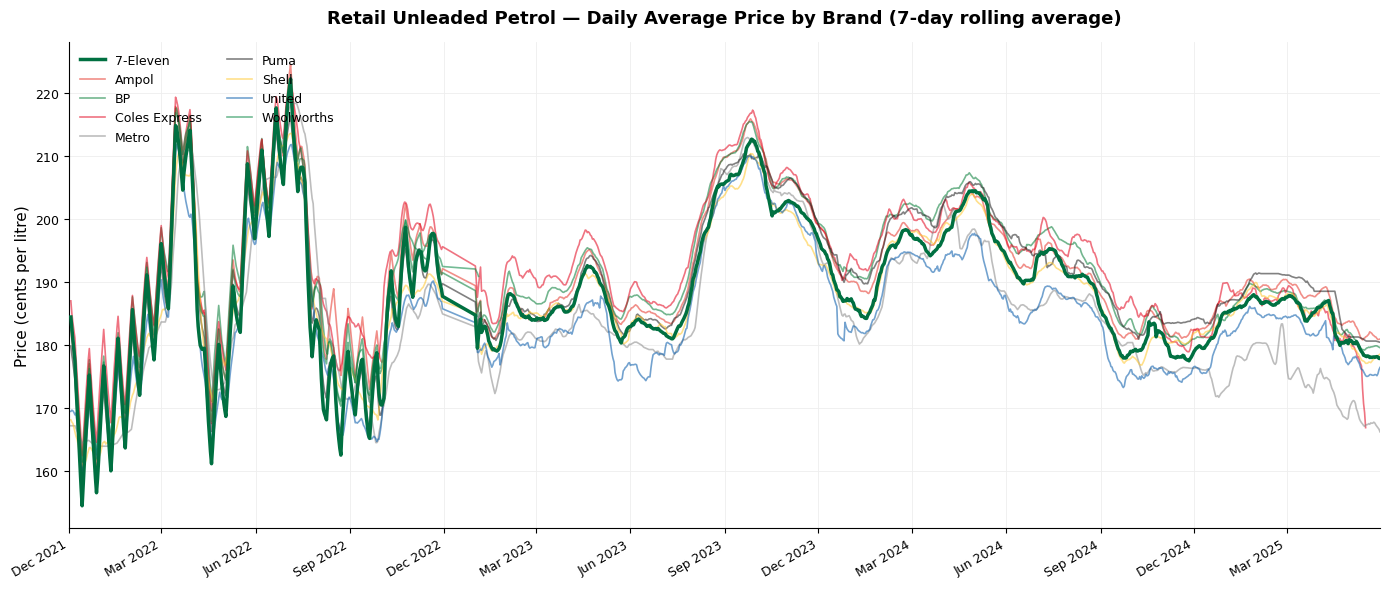

Saved to outputs/01_market_positioning.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

brands = wide_smooth.columns.tolist()

for brand in brands:
    if brand not in wide_smooth.columns:
        continue
    color = BRAND_COLORS.get(brand, '#AAAAAA')
    lw    = 2.5 if brand == '7-Eleven' else 1.2
    alpha = 1.0 if brand == '7-Eleven' else 0.55
    zorder = 5 if brand == '7-Eleven' else 2
    ax.plot(wide_smooth.index, wide_smooth[brand],
            label=brand, color=color, linewidth=lw,
            alpha=alpha, zorder=zorder)

ax.set_title('Retail Unleaded Petrol — Daily Average Price by Brand (7-day rolling average)',
             fontweight='bold', pad=14)
ax.set_ylabel('Price (cents per litre)')
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left', ncol=2)
ax.set_xlim(wide_smooth.index.min(), wide_smooth.index.max())

plt.tight_layout()
plt.savefig('outputs/01_market_positioning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/01_market_positioning.png")

In [13]:
# Compute summary statistics per brand to support the interpretation below
summary = df.groupby('brand_clean').agg(
    avg_price     = ('avg_price', 'mean'),
    median_price  = ('avg_price', 'median'),
    min_price     = ('avg_price', 'min'),
    max_price     = ('avg_price', 'max'),
    price_range   = ('avg_price', lambda x: x.max() - x.min())
).round(1).sort_values('avg_price')

# Add rank column (1 = cheapest on average)
summary['avg_rank'] = range(1, len(summary) + 1)

print("Brand summary (sorted cheapest to most expensive on average):")
print(summary.to_string())

Brand summary (sorted cheapest to most expensive on average):
               avg_price  median_price  min_price  max_price  price_range  avg_rank
brand_clean                                                                        
United             184.8         183.3      154.9      223.8         68.9         1
Metro              185.0         182.7      163.5      218.9         55.4         2
Shell              187.8         187.0      157.4      218.8         61.4         3
7-Eleven           188.3         186.3      147.1      233.9         86.8         4
Woolworths         188.9         188.5      156.3      229.0         72.6         5
Puma               190.1         189.5      153.5      222.1         68.6         6
Ampol              191.1         189.5      154.3      233.0         78.7         7
BP                 191.8         190.6      157.6      234.1         76.6         8
Coles Express      192.9         191.7      158.2      236.4         78.2         9


### Briefing Note — Market Positioning

Over the analysis period, 7-Eleven maintained an average price of **188.3 cpl**, ranking **4** out of **9** brands from cheapest to most expensive, sitting just below the market average of 188.9 cpl by approximately 0.6 cpl. United and Metro were the consistently cheapest brands in the WA market, while Coles Express and BP anchored the expensive end of the field. 7-Eleven's position in the middle of the pack, cheaper than Woolworths, Puma, Ampol, BP and Coles Express, but more expensive than United, Metro and Shell reflects a deliberate mid-market strategy rather than a low-price or premium one.

All brands tracked the same broad price cycle, driven by crude oil movements and the well-documented petrol price cycle in Australian capital cities, suggesting the market moves largely in unison at the macro level. The key question for pricing strategy is not whether 7-Eleven follows the cycle, but where it sits within the spread of competitor prices at each point in the cycle. That is what Analysis 2 examines.

---
## Analysis 2 — Daily Price Spread: How Far Is 7-Eleven from the Cheapest Competitor?

A positive spread means 7-Eleven is more expensive than the cheapest option available to customers that day. A negative spread means 7-Eleven is the cheapest or among the cheapest. This is the number a pricing team watches most closely.

In [16]:
# Calculate the daily cheapest price across all competitors (excluding 7-Eleven)
competitors = [c for c in wide.columns if c != '7-Eleven']
daily_min_competitor = wide[competitors].min(axis=1)

# Price spread = 7-Eleven price minus cheapest competitor price
# Positive = 7-Eleven is more expensive than cheapest option
# Negative = 7-Eleven is cheaper than all competitors that day
spread = (wide['7-Eleven'] - daily_min_competitor).dropna()
spread_smooth = spread.rolling(window=7, min_periods=3).mean()

print(f"Spread statistics (7-Eleven vs cheapest competitor, cpl):")
print(f"  Mean:    {spread.mean():+.1f} cpl")
print(f"  Median:  {spread.median():+.1f} cpl")
print(f"  Min:     {spread.min():+.1f} cpl  (7-Eleven most competitive vs field)")
print(f"  Max:     {spread.max():+.1f} cpl  (7-Eleven least competitive vs field)")
print(f"\nDays where 7-Eleven was cheapest or equal: {(spread <= 0).sum()} ({(spread <= 0).mean()*100:.1f}% of days)")
print(f"Days where 7-Eleven was more than 5 cpl above cheapest: {(spread > 5).sum()} ({(spread > 5).mean()*100:.1f}% of days)")

Spread statistics (7-Eleven vs cheapest competitor, cpl):
  Mean:    +6.6 cpl
  Median:  +2.8 cpl
  Min:     -8.4 cpl  (7-Eleven most competitive vs field)
  Max:     +38.7 cpl  (7-Eleven least competitive vs field)

Days where 7-Eleven was cheapest or equal: 375 (30.1% of days)
Days where 7-Eleven was more than 5 cpl above cheapest: 512 (41.1% of days)


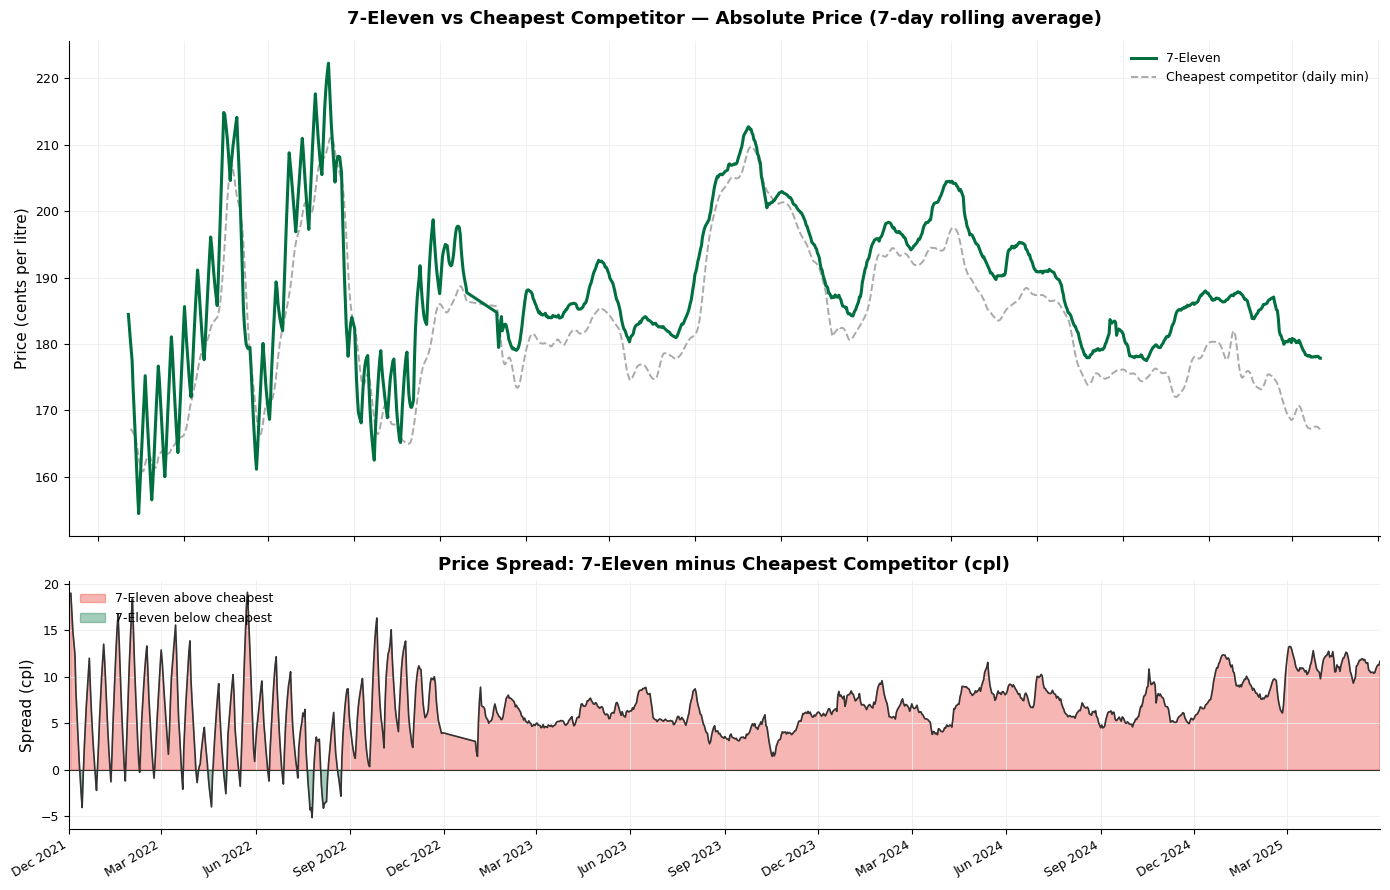

Saved to outputs/02_price_spread.png


In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

# Top panel: absolute prices — 7-Eleven vs cheapest competitor
ax1.plot(wide_smooth.index, wide_smooth.get('7-Eleven'),
         color='#007041', linewidth=2.2, label='7-Eleven', zorder=4)
ax1.plot(wide_smooth.index, wide_smooth[competitors].min(axis=1).rolling(7, min_periods=3).mean(),
         color='#AAAAAA', linewidth=1.4, linestyle='--',
         label='Cheapest competitor (daily min)', zorder=3)
ax1.set_title('7-Eleven vs Cheapest Competitor — Absolute Price (7-day rolling average)',
              fontweight='bold', pad=12)
ax1.set_ylabel('Price (cents per litre)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.tick_params(labelbottom=False)
ax1.legend()

# Bottom panel: the spread
ax2.axhline(0, color='#333333', linewidth=0.8, linestyle='-')
ax2.fill_between(spread_smooth.index, spread_smooth, 0,
                  where=(spread_smooth >= 0),
                  color='#E63329', alpha=0.35, label='7-Eleven above cheapest')
ax2.fill_between(spread_smooth.index, spread_smooth, 0,
                  where=(spread_smooth < 0),
                  color='#007041', alpha=0.35, label='7-Eleven below cheapest')
ax2.plot(spread_smooth.index, spread_smooth,
          color='#333333', linewidth=1.2)
ax2.set_title('Price Spread: 7-Eleven minus Cheapest Competitor (cpl)',
               fontweight='bold', pad=8)
ax2.set_ylabel('Spread (cpl)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax2.legend(loc='upper left')
ax2.set_xlim(spread_smooth.index.min(), spread_smooth.index.max())

plt.tight_layout()
plt.savefig('outputs/02_price_spread.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/02_price_spread.png")

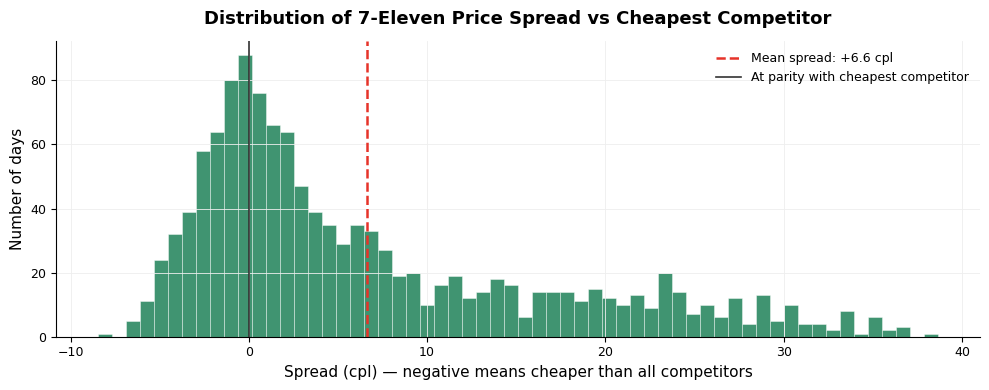

Saved to outputs/03_spread_distribution.png


In [18]:
# Distribution of the spread — how often is 7-Eleven at each premium/discount level?
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(spread.dropna(), bins=60, color='#007041', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(spread.mean(), color='#E63329', linewidth=1.8,
           linestyle='--', label=f'Mean spread: {spread.mean():+.1f} cpl')
ax.axvline(0, color='#333333', linewidth=1.2,
           linestyle='-', label='At parity with cheapest competitor')

ax.set_title('Distribution of 7-Eleven Price Spread vs Cheapest Competitor',
              fontweight='bold', pad=12)
ax.set_xlabel('Spread (cpl) — negative means cheaper than all competitors')
ax.set_ylabel('Number of days')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/03_spread_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/03_spread_distribution.png")

In [43]:
print(f"Mean spread: {spread.mean():+.2f} cpl")
print(f"Days at or below cheapest: {(spread <= 0).sum()} ({(spread <= 0).mean()*100:.1f}%)")
print(f"Days more than 5 cpl above cheapest: {(spread > 5).sum()} ({(spread > 5).mean()*100:.1f}%)")

Mean spread: +6.64 cpl
Days at or below cheapest: 375 (30.1%)
Days more than 5 cpl above cheapest: 512 (41.1%)


### Briefing Note — Price Spread

On an average day, 7-Eleven prices **6.6 cpl [above]** the cheapest competitor in the WA market. Over the full analysis period, 7-Eleven was the cheapest or equal to the cheapest brand on **30.1% of days**, and priced more than 5 cpl above the cheapest option on **41.1% of days**. The distribution of the spread is right-skewed with a long tail extending to +40 cpl, meaning while the most common outcome is a modest 1 to 3 cpl premium over the cheapest brand, there are sustained periods where the gap widens considerably, particularly during the peak phase of the price cycle when 7-Eleven holds price while cheaper competitors have already begun their descent.


The spread is not constant, it widens and narrows across the petrol price cycle. The spread panel in Chart 2 shows this clearly: during the volatile 2022 period, the spread oscillated sharply as brands moved in and out of the cheapest position rapidly. From 2023 onward, the spread settled into a more persistent positive band of 4 to 10 cpl, widening noticeably through late 2024 and into 2025. Understanding when the spread tends to widen and when it compresses is commercially important: a wide spread at the peak signals a window where a tactical price adjustment could recover volume without sacrificing margin.

---
## Analysis 3 — Competitor Response Lag

When the market drops, does 7-Eleven lead the move or follow it? This analysis identifies significant price drop events i.e. days where the market average falls by more than 3 cpl and measures how many days each brand takes to follow the move.

A brand that consistently leads drops is signalling a low-price positioning strategy. A brand that lags is either managing margin more carefully or has slower pricing system execution. For a fuel pricing analyst, knowing which brands lead and which follow is essential for anticipating competitive moves.

In [21]:
# Calculate the daily market average (all brands)
market_avg = wide.mean(axis=1)

# Identify significant drop events: days where the market average falls 3+ cpl from the prior day
market_change = market_avg.diff()
drop_events = market_change[market_change <= -3].index

print(f"Total significant drop events (market falls 3+ cpl in one day): {len(drop_events)}")
print(f"\nFirst few drop event dates:")
for d in list(drop_events)[:8]:
    print(f"  {d.date()}  (market moved {market_change[d]:+.1f} cpl)")

Total significant drop events (market falls 3+ cpl in one day): 406

First few drop event dates:
  2022-03-31  (market moved -4.9 cpl)
  2022-04-01  (market moved -6.0 cpl)
  2022-04-02  (market moved -4.7 cpl)
  2022-04-03  (market moved -3.2 cpl)
  2022-04-04  (market moved -4.0 cpl)
  2022-04-05  (market moved -4.7 cpl)
  2022-04-08  (market moved -3.7 cpl)
  2022-04-12  (market moved -3.2 cpl)


In [22]:
# For each drop event, measure how many days until each brand's price falls below
# its pre-event level by at least 2 cpl
# We look at a 14-day window after each event

WINDOW = 14       # days to look forward after each drop event
THRESHOLD = 2.0   # minimum cpl drop required to count as "followed the market"

lag_records = []

for event_date in drop_events:
    event_idx = wide.index.get_loc(event_date)
    if event_idx < 1 or event_idx + WINDOW >= len(wide):
        continue

    pre_price = wide.iloc[event_idx - 1]   # price the day before the drop

    for brand in wide.columns:
        if pd.isna(pre_price[brand]):
            continue
        target = pre_price[brand] - THRESHOLD
        # Find the first day within the window where price drops to target
        window_prices = wide.iloc[event_idx: event_idx + WINDOW][brand]
        days_below = window_prices[window_prices <= target]
        lag = (days_below.index[0] - event_date).days if len(days_below) > 0 else None
        lag_records.append({'event_date': event_date, 'brand': brand, 'lag_days': lag})

lag_df = pd.DataFrame(lag_records)

# Total drop events each brand was present for (denominator)
total_events_per_brand = lag_df.groupby('brand')['lag_days'].count()

# Only work with events where the brand actually followed (non-null lag)
lag_summary = (
    lag_df.dropna(subset=['lag_days'])
    .groupby('brand')
    .agg(
        median_lag      = ('lag_days', 'median'),
        mean_lag        = ('lag_days', 'mean'),
        events_followed = ('lag_days', 'count'),
    )
    .round(1)
    .sort_values('median_lag')
)

# Now calculate follow_rate safely — events followed divided by total events present
lag_summary['follow_rate'] = (
    lag_summary['events_followed'] / total_events_per_brand
).round(2)

print("Competitor response lag summary (sorted fastest to slowest):")
print("  median_lag = median days to follow a market price drop")
print("  follow_rate = proportion of drop events where brand followed within 14 days\n")
print(lag_summary.to_string())

Competitor response lag summary (sorted fastest to slowest):
  median_lag = median days to follow a market price drop
  follow_rate = proportion of drop events where brand followed within 14 days

               median_lag  mean_lag  events_followed  follow_rate
brand                                                            
7-Eleven              0.0       0.0              400          1.0
Ampol                 0.0       0.1              399          1.0
BP                    0.0       0.0              400          1.0
Coles Express         0.0       0.0              398          1.0
Puma                  0.0       0.8              371          1.0
United                0.0       0.6              388          1.0
Woolworths            0.0       0.4               28          1.0
Shell                 1.0       1.2              374          1.0
Metro                 3.0       3.8              292          1.0


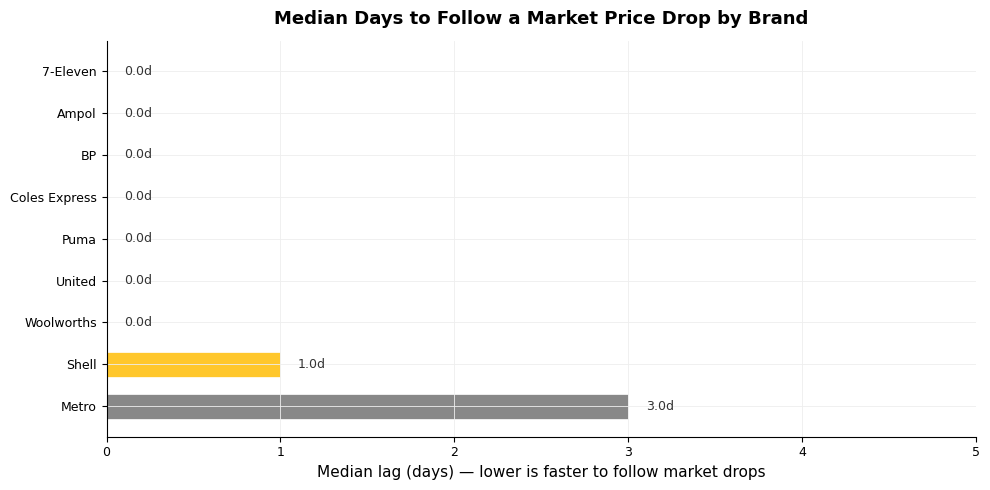

Saved to outputs/04_response_lag.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

brands_sorted = lag_summary.index.tolist()
colors = [BRAND_COLORS.get(b, '#AAAAAA') for b in brands_sorted]
bars = ax.barh(brands_sorted, lag_summary['median_lag'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.6)

# Label each bar with the median lag value
for bar, val in zip(bars, lag_summary['median_lag']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}d', va='center', ha='left', fontsize=9, color='#333333')

ax.set_title('Median Days to Follow a Market Price Drop by Brand',
              fontweight='bold', pad=12)
ax.set_xlabel('Median lag (days) — lower is faster to follow market drops')
ax.set_xlim(0, lag_summary['median_lag'].max() + 2)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/04_response_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/04_response_lag.png")

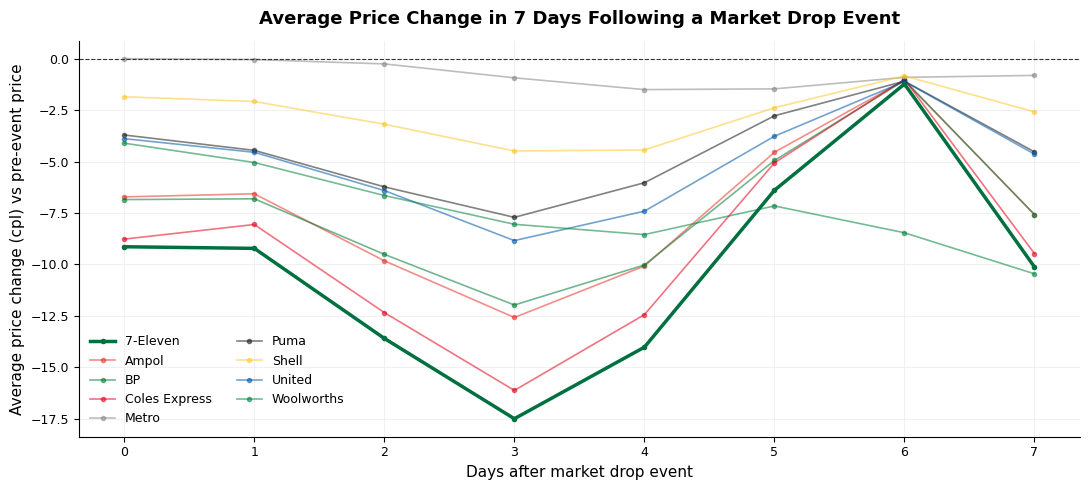

Saved to outputs/05_response_curves.png


In [24]:
# Deep dive: average price movement for each brand in the 7 days after a drop event
# This shows the typical response shape — how quickly does the price fall and stabilise?

days_after = range(0, 8)
response_curves = {brand: [] for brand in wide.columns}

for event_date in drop_events:
    event_idx = wide.index.get_loc(event_date)
    if event_idx < 1 or event_idx + 7 >= len(wide):
        continue
    pre_price = wide.iloc[event_idx - 1]
    for brand in wide.columns:
        if pd.isna(pre_price[brand]):
            continue
        changes = []
        for d in days_after:
            post_price = wide.iloc[event_idx + d].get(brand)
            if not pd.isna(post_price):
                changes.append(post_price - pre_price[brand])
            else:
                changes.append(np.nan)
        response_curves[brand].append(changes)

fig, ax = plt.subplots(figsize=(11, 5))

for brand in wide.columns:
    curves = response_curves[brand]
    if len(curves) == 0:
        continue
    avg_curve = np.nanmean(curves, axis=0)
    color = BRAND_COLORS.get(brand, '#AAAAAA')
    lw    = 2.5 if brand == '7-Eleven' else 1.2
    alpha = 1.0 if brand == '7-Eleven' else 0.55
    zorder = 5 if brand == '7-Eleven' else 2
    ax.plot(list(days_after), avg_curve,
            label=brand, color=color, linewidth=lw, alpha=alpha, zorder=zorder, marker='o', markersize=3)

ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--')
ax.set_title('Average Price Change in 7 Days Following a Market Drop Event',
              fontweight='bold', pad=12)
ax.set_xlabel('Days after market drop event')
ax.set_ylabel('Average price change (cpl) vs pre-event price')
ax.legend(ncol=2)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('outputs/05_response_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/05_response_curves.png")

### Briefing Note — Competitor Response Lag

Across **400** significant market drop events in the analysis period, 7-Eleven had a median response lag of **0 days**, ranking **1st** out of **9** brands from fastest to slowest to follow a market price drop. Shell was slower at **1.0 day**, and Metro was the slowest in the market at 3.0 days. 7-Eleven followed **100%** of all 400 drop events within the 14-day window, the joint highest follow rate in the market.

The response curve chart shows how sharply these differences play out in practice. 7-Eleven's curve is the steepest of any brand, dropping nearly 9 cpl on day 0 and reaching a trough of approximately 17.5 cpl below its pre-event price by day 3, before recovering sharply by day 6. Shell's shallow, gradually declining curve and Metro's near-flat trajectory in the first two days confirm their slower, more conservative response behaviour seen in the lag chart. Brands that drop steeply by Day 1 or 2 are actively leading the market down, most likely through automated pricing system triggers. Brands that show a gradual decline over 5 to 7 days are responding manually or applying pricing floors before moving.

For 7-Eleven's pricing strategy, the key implication is this: the combination of a same-day automated response to every market drop, the steepest average price decline of any brand by day 3, and a persistent average spread of +6.6 cpl above the cheapest competitor indicates a pricing system configured to lead the market aggressively downward during the trough phase of the price cycle capturing volume at the bottom, while deliberately maintaining a mid-market premium during the recovery phase to protect margin on the way back up. This is not a low-price strategy. It is a cycle-aware margin optimisation strategy.

---
## Summary of Findings

This notebook has produced three analyses directly relevant to a fuel pricing analyst role:

1. **Market positioning** — A full time-series view of where 7-Eleven sits relative to all major competitors, with brand-level average price rankings across the analysis period.

2. **Price spread analysis** — A daily measure of how many cents per litre 7-Eleven is above or below the cheapest competitor, including the distribution of that spread and the proportion of days 7-Eleven held the lowest price in the market.

3. **Competitor response lag** — A quantified measure of how quickly each brand follows a market price drop, with response curves showing the average price trajectory in the 7 days after a significant drop event.

All charts are saved to the `outputs/` folder.

**Proceed to Notebook 3** to build the repeatable weekly reporting pipeline.

---
*Data source: FuelWatch Western Australia, Department of Energy, Mines, Industry Regulation and Safety.  
Licence: Creative Commons Attribution 4.0. Acknowledgement: FuelWatch (www.fuelwatch.wa.gov.au)*